# 01 Datenbeschaffung und Aufbereitung
**Multi-Country-BIP-Prognose**

Dieses Notebook deckt **CRISP-DM Phase 2 (Data Understanding)** und **Phase 3 (Data Preparation)** ab und bildet die Datengrundlage für alle weiteren Notebooks.

| Notebook | nutzt aus diesem Notebook |
|---|---|
| `02_SARIMAX` | `data/processed/gdp_panel.csv` via `src.data_utils.load_panel()` |
| `03_TFT` | dito, zusätzlich `panel_meta.json` mit Feature-Gruppen und Splits |
| `04_Chronos` | dito |
| `05_Vergleich` | zusätzlich `data/results/preds_*.csv` aller Modelle |

Für das Datenhandling gilt eine feste Regel. Jedes Modell-Notebook speichert seine Prognosen über `src.evaluation.save_predictions(df, "<modell>")` im standardisierten Schema `src.config.RESULTS_COLUMNS`, denn nur so kann Notebook 05 fair vergleichen.

## 0 Setup

In [1]:
import sys
from pathlib import Path

# Projekt-Wurzel (CapstoneProjekt_BPI) in den Pfad, damit `src` importierbar ist.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_utils, evaluation, plotting

plotting.apply_style()
pd.set_option("display.max_columns", 30)

# Nur der Ordnername, damit die Ausgabe auf jedem Rechner gleich aussieht.
print("Projekt-Wurzel:", ROOT.name)

Projekt-Wurzel: CapstoneProjekt_BPI


## 1 Welche Daten und warum

Wir prognostizieren **reales BIP-Wachstum** und nicht das BIP-Niveau. Wachstumsraten sind über Länder vergleichbar, näherungsweise stationär und genau die Größe, auf die Entscheidungen in der Haushalts- und Investitionsplanung reagieren.

Die exogenen Treiber stammen bewusst aus der **empirischen Wachstumsökonomik**, also aus dem Solow-Modell und den Growth-Regressions nach Barro. Dazu zählen Demografie, Investitionsquote, Konvergenz über das Ausgangsniveau des Pro-Kopf-BIP, Handelsoffenheit sowie makroökonomische Stabilität über die Inflation.

Entscheidend ist die Trennung in zwei Gruppen, unsere Anti-Leakage-Regel:

1. **Im Voraus bekannt** (`KNOWN_FUTURE`), das sind die Demografie-Variablen. Die UN veröffentlicht Bevölkerungsprojektionen über Jahrzehnte, die Altersstruktur in fünf Jahren gilt damit als bekannt. Diese Variablen dürfen Modelle als *known future covariates* nutzen, der TFT kann das nativ.
2. **Nur in der Vergangenheit bekannt** (`PAST_ONLY`), das sind Investitionen, Handel, Inflation und Pro-Kopf-BIP. Deren Zukunftswerte kennt zur Prognosezeit niemand, sie gehen deshalb **ausschließlich gelaggt** (t−1) ins Panel ein. Die kontemporären Spalten werden beim Aufbereiten **gelöscht**, damit Leakage konstruktiv unmöglich ist.

Alle Codes stammen aus den **World Development Indicators (WDI)** der World Bank, rund 217 Volkswirtschaften, jährlich ab 1960, lizenziert unter CC-BY-4.0.

In [2]:
uebersicht = pd.DataFrame(
    [(code_, name, desc,
      "Ziel" if name == config.TARGET
      else "Referenz/Skala" if name == "gdp_pc"
      else "exogen — im Voraus bekannt" if name in config.KNOWN_FUTURE
      else "exogen — nur gelaggt (t-1)")
     for code_, (name, desc) in config.INDICATORS.items()],
    columns=["WDI-Code", "Panel-Spalte", "Beschreibung", "Rolle"])
uebersicht

,WDI-Code,Panel-Spalte,Beschreibung,Rolle
0,NY.GDP.MKTP.KD.ZG,gdp_growth,Reales BIP-Wachstum (% p.a.),Ziel
1,NY.GDP.PCAP.KD,gdp_pc,Reales BIP pro Kopf (konst. 2015 US$),Referenz/Skala
2,SP.POP.GROW,pop_growth,Bevölkerungswachstum (% p.a.),exogen — im Voraus bekannt
3,SP.POP.1564.TO.ZS,working_age_share,Anteil 15-64-Jährige (%),exogen — im Voraus bekannt
4,SP.POP.DPND,dependency_ratio,Abhängigenquote (% der 15-64-J.),exogen — nur gelaggt (t-1)
5,NE.GDI.TOTL.ZS,investment_gdp,Bruttoinvestitionen (% des BIP),exogen — nur gelaggt (t-1)
6,NE.TRD.GNFS.ZS,trade_gdp,"Handel, Exporte+Importe (% des BIP)",exogen — nur gelaggt (t-1)
7,FP.CPI.TOTL.ZG,inflation,"Inflation, Verbraucherpreise (% p.a.)",exogen — nur gelaggt (t-1)
8,SP.POP.TOTL,population,"Bevölkerung, gesamt (Personen)",exogen — nur gelaggt (t-1)


## 2 Download und Data Gate

`download_wdi()` lädt alle Indikatoren für **alle echten Länder**, wobei Aggregate wie *World* oder *Euro area* über `skipAggs` ausgeschlossen werden, und legt das Ergebnis unter `data/raw/` im Cache ab. Der erste Lauf dauert einige Minuten, danach greift der Cache. Kommt später ein neuer Indikator hinzu, lädt die Funktion nur diesen nach.

Das anschließende Data Gate prüft zweierlei. Erstens, ob alle erwarteten Indikatoren angekommen sind. Zweitens, ob die Werte in einem plausiblen Bereich liegen, damit stille Datenfehler nicht unbemerkt ins Panel wandern.

In [3]:
raw = data_utils.download_wdi()          # force=True erzwingt Neuladen
meta = data_utils.download_country_meta()

print(f"{raw.shape[0]:,} Zeilen | {raw['country'].nunique()} Länder | "
      f"Jahre {raw['year'].min()}–{raw['year'].max()}")
raw.head()

Cache-Treffer: C:\Users\antoi\Documents\repos\AI-for-Business-Prognosis\CapstoneProjekt_BPI\data\raw\wdi_raw_long.csv (force=True zum Neuladen)
126,945 Zeilen | 217 Länder | Jahre 1960–2024


,country,year,indicator,value
0,ABW,1960,dependency_ratio,83.046159
1,ABW,1961,dependency_ratio,81.969092
2,ABW,1962,dependency_ratio,81.058317
3,ABW,1963,dependency_ratio,79.794348
4,ABW,1964,dependency_ratio,78.152923


In [4]:
# Data Gate, Teil 1: Sind alle Indikatoren wirklich angekommen?
gate = (raw.dropna(subset=["value"])
           .groupby("indicator")
           .agg(laender=("country", "nunique"),
                erstes_jahr=("year", "min"),
                letztes_jahr=("year", "max"),
                werte=("value", "size"),
                minimum=("value", "min"),
                maximum=("value", "max")))
assert set(gate.index) == {n for n, _ in config.INDICATORS.values()}, "Indikator fehlt!"

# Data Gate, Teil 2: Liegen die Werte in einem plausiblen Bereich?
# Die Grenzen sind bewusst weit gewählt. Sie sollen echte Datenfehler fangen,
# etwa negative Bevölkerung oder Anteile über 100 Prozent, nicht aber reale
# Extremfälle wie Hyperinflation oder Nachkriegs-Erholungen.
plausibel = {
    "gdp_growth":        (-90, 200),       # Prozent p.a.
    "gdp_pc":            (0, 500_000),     # US-Dollar, konstant
    "pop_growth":        (-40, 40),        # Prozent p.a.
    "working_age_share": (0, 100),         # Anteil in Prozent
    "dependency_ratio":  (0, 300),         # Quote in Prozent
    "investment_gdp":    (-50, 200),       # Prozent des BIP
    "trade_gdp":         (0, 1_500),       # Prozent des BIP
    "inflation":         (-100, 100_000),  # Prozent p.a., Hyperinflation
    "population":        (0, 2e9),         # Personen
}
gate["erwartet_von"] = [plausibel[i][0] for i in gate.index]
gate["erwartet_bis"] = [plausibel[i][1] for i in gate.index]
gate["plausibel"] = [
    plausibel[i][0] <= gate.loc[i, "minimum"] and gate.loc[i, "maximum"] <= plausibel[i][1]
    for i in gate.index
]

ausreisser = gate[~gate["plausibel"]]
assert ausreisser.empty, f"Werte ausserhalb des plausiblen Bereichs\n{ausreisser}"
print("Data Gate bestanden, alle Indikatoren vollständig und im plausiblen Bereich.")
gate

Data Gate bestanden, alle Indikatoren vollständig und im plausiblen Bereich.


,laender,erstes_jahr,letztes_jahr,werte,minimum,maximum,erwartet_von,erwartet_bis,plausibel
indicator,,,,,,,,,
dependency_ratio,217,1960,2024,14075,17.302757,1.745084e+02,0,3.000000e+02,True
gdp_growth,214,1961,2024,11221,-64.047107,1.499730e+02,-90,2.000000e+02,True
gdp_pc,213,1960,2024,11346,122.678901,2.471701e+05,0,5.000000e+05,True
inflation,193,1960,2024,8971,-17.640424,2.377313e+04,-100,1.000000e+05,True
investment_gdp,187,1960,2024,8539,-15.678444,7.678232e+01,-50,2.000000e+02,True
pop_growth,217,1961,2024,13856,-27.470786,2.170034e+01,-40,4.000000e+01,True
population,217,1960,2024,14075,2715.000000,1.450936e+09,0,2.000000e+09,True
trade_gdp,194,1960,2024,8891,0.000000,8.631951e+02,0,1.500000e+03,True
working_age_share,217,1960,2024,14105,36.428742,8.524949e+01,0,1.000000e+02,True


## 3 Data Understanding

### 3.1 Vom Long-Format zum Panel

Eine Zeile je *(Land, Jahr)* und eine Spalte je Indikator. Das ist das Standard-Format für alle Modelle.

In [5]:
panel = data_utils.build_panel(raw)
print(panel.shape)
panel.head()

(14105, 11)


,country,year,dependency_ratio,gdp_growth,gdp_pc,inflation,investment_gdp,pop_growth,population,trade_gdp,working_age_share
0,ABW,1960,83.046159,NaN,NaN,NaN,NaN,NaN,54922.0,NaN,54.632024
1,ABW,1961,81.969092,NaN,NaN,NaN,NaN,1.187344,55578.0,NaN,54.953804
2,ABW,1962,81.058317,NaN,NaN,NaN,NaN,1.326227,56320.0,NaN,55.230824
3,ABW,1963,79.794348,NaN,NaN,NaN,NaN,1.203664,57002.0,NaN,55.618712
4,ABW,1964,78.152923,NaN,NaN,NaN,NaN,1.076602,57619.0,NaN,56.131658


### 3.2 Wie vollständig sind die Daten

Typisch für die WDI berichten in den 1960er Jahren nur wenige Länder, ab etwa 1990 dann fast alle. Die Demografie-Reihen sind nahezu lückenlos, weil die UN sie interpoliert. Die makroökonomischen Reihen wie Inflation und Investitionen haben deutlich mehr Lücken.

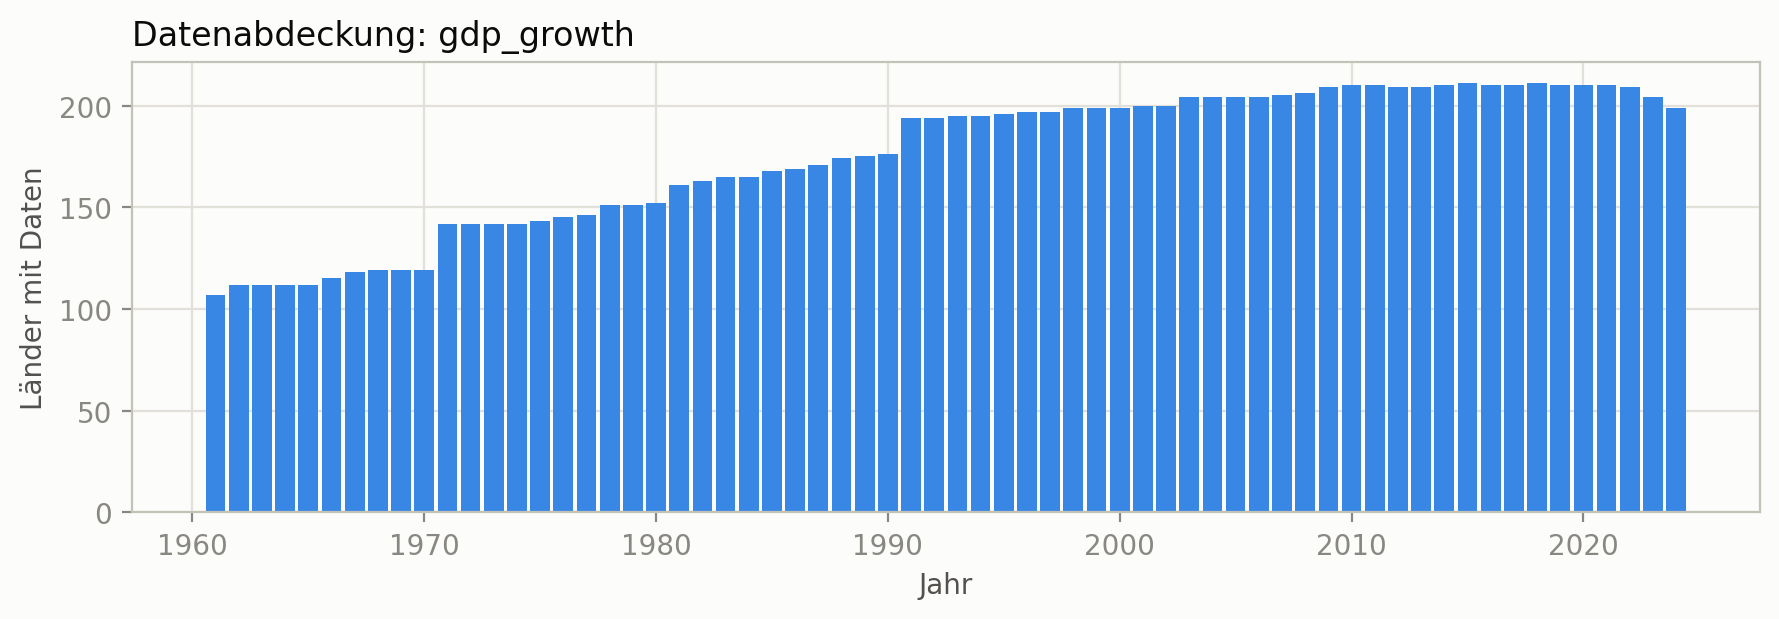

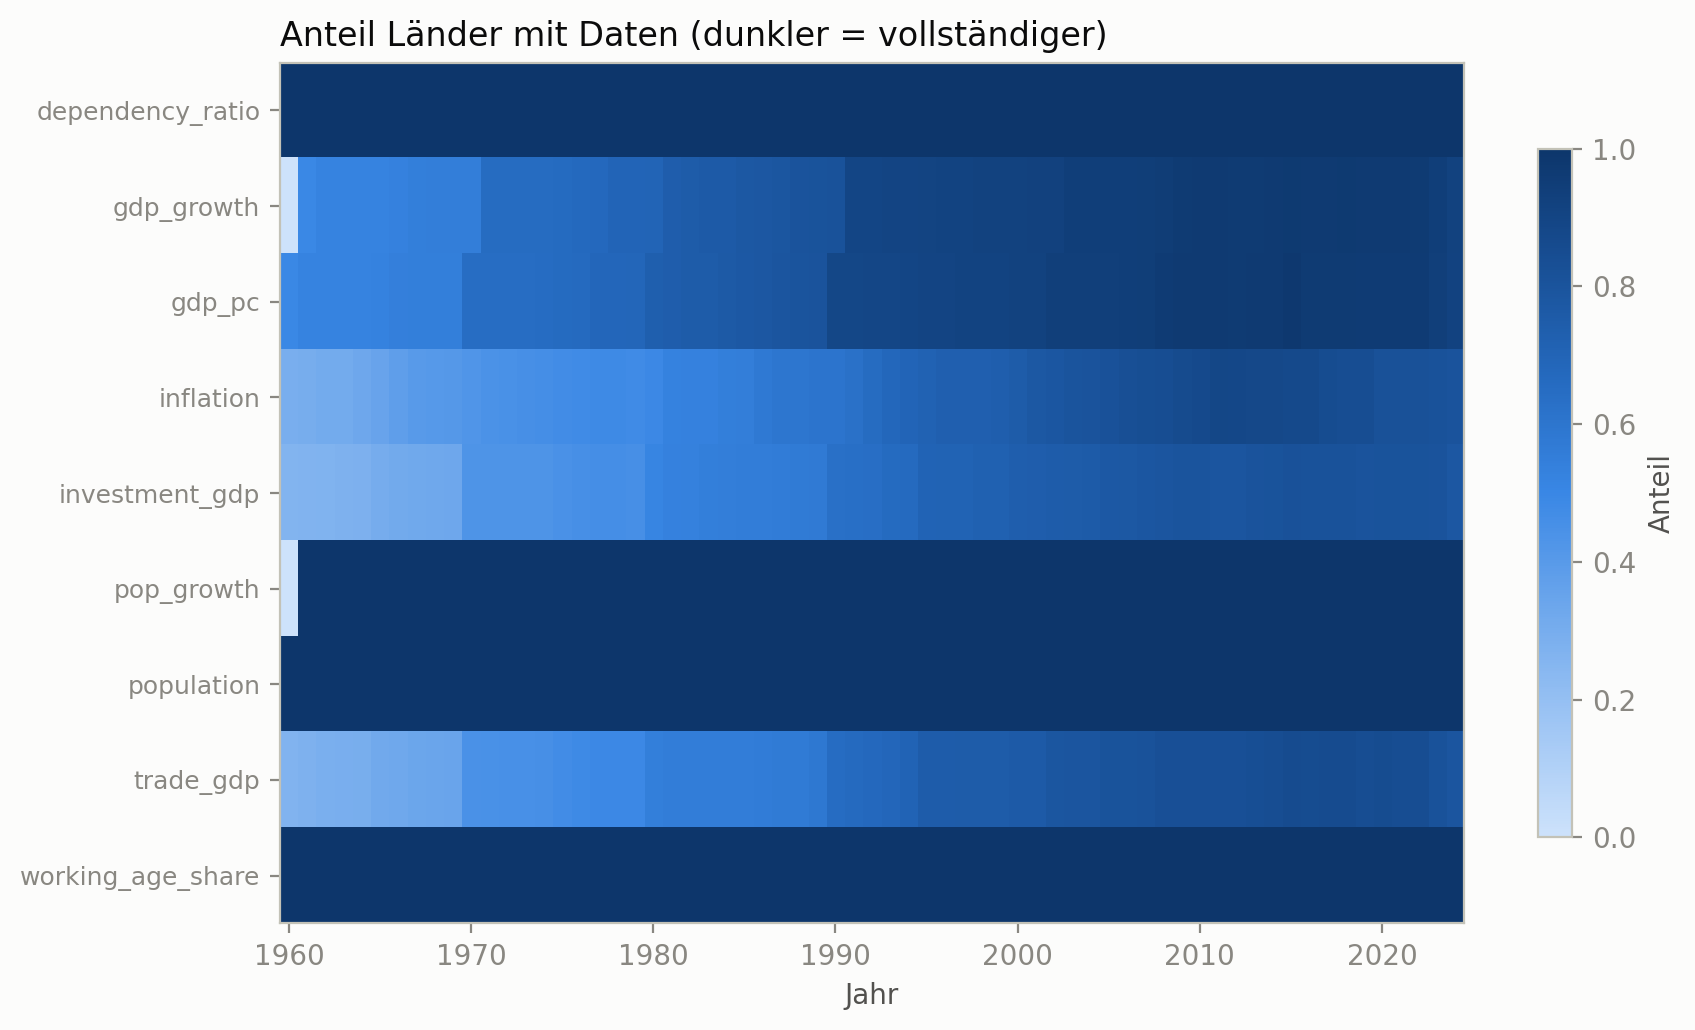

In [6]:
plotting.plot_coverage(panel, config.TARGET)
plotting.plot_missing_matrix(panel)
plt.show()

### 3.3 Länderfilter

Für ein sauberes Backtesting ab Origin 1999 brauchen wir Länder mit langer und aktueller Historie. Die Kriterien stehen zentral in `src.config` und lauten:

* mindestens **35 Jahre** mit gültigem BIP-Wachstum (`MIN_YEARS = 35`),
* ein gültiger Wert am aktuellen Rand, also 2023 oder 2024, sodass Länder ohne aktuelle Meldung herausfallen,
* mindestens **80 Prozent Abdeckung** jeder exogenen Treibervariable ab 1995 (`MIN_EXOG_COVERAGE = 0.8` und `EXOG_SINCE = 1995`).

Warum genau diese Werte gewählt wurden:

* Die **35 Jahre** folgen aus der Backtest-Konvention. Der früheste Origin ist 1999 und der letzte Testwert liegt 2024, eine Reihe muss also über das gesamte Fenster tragen. Bei 35 gültigen Jahren bis 2024 beginnt die Historie spätestens 1990. Damit hat schon der erste Fold eine belastbare Trainingsphase, und länderweise geschätzte Modelle wie SARIMAX haben bei Jahresdaten genügend Beobachtungen für eine stabile Parameterschätzung. Zugleich deckt dieser Zeitraum mindestens zwei vollständige Konjunkturzyklen ab.
* Der **aktuelle Rand** verhindert, dass Länder im finalen Holdout von 2020 bis 2024 ohne Zielwerte dastehen und die Auswertung verzerren.
* Die **80 Prozent ab 1995** sichern, dass jedes Land im Testfenster tatsächlich Regressoren besitzt. Ohne dieses Kriterium würden die Modelle unbemerkt auf unterschiedlichen Ländermengen prognostizieren, was den Vergleich in Notebook 05 unfair machen würde. Das Startjahr 1995 ist gewählt, weil die exogenen Reihen davor spürbar lückenhafter sind und der früheste Origin ohnehin erst 1999 beginnt.

Das ist ein bewusster Kompromiss. Wir verlieren einige kleine oder junge Staaten wie den Südsudan, gewinnen aber ein stabiles Panel, in dem jedes Land alle Backtest-Folds durchläuft.

In [7]:
panel_f, report = data_utils.filter_countries(panel)

print(f"Behalten: {report['kept'].sum()} Länder | "
      f"Verworfen: {(~report['kept']).sum()} Länder")
print("\nBeispiele verworfener Länder (zu kurze/inaktuelle Historie):")
report[~report["kept"]].head(8)

Behalten: 116 Länder | Verworfen: 101 Länder

Beispiele verworfener Länder (zu kurze/inaktuelle Historie):


,n_years,last_valid_year,exog_coverage,kept
country,,,,
BDI,64.0,2024.0,0.00,False
ARG,64.0,2024.0,0.23,False
BRB,64.0,2024.0,0.00,False
BMU,64.0,2024.0,0.00,False
GUY,64.0,2024.0,0.37,False
COD,64.0,2024.0,0.73,False
MMR,64.0,2024.0,0.00,False
NGA,64.0,2024.0,0.00,False


### 3.4 Ein Blick in die Zielvariable

Der erste Plot zeigt sehr unterschiedliche Wachstumspfade zwischen Industrie- und Schwellenländern. Das ist das zentrale Argument für ein **globales Modell mit Cross-Learning**. Der zweite Plot zeigt eine Verteilung mit schweren Rändern, in der die globalen Krisen 2009 und 2020 klar hervortreten. Genau dafür führen wir später den Krisen-Dummy ein.

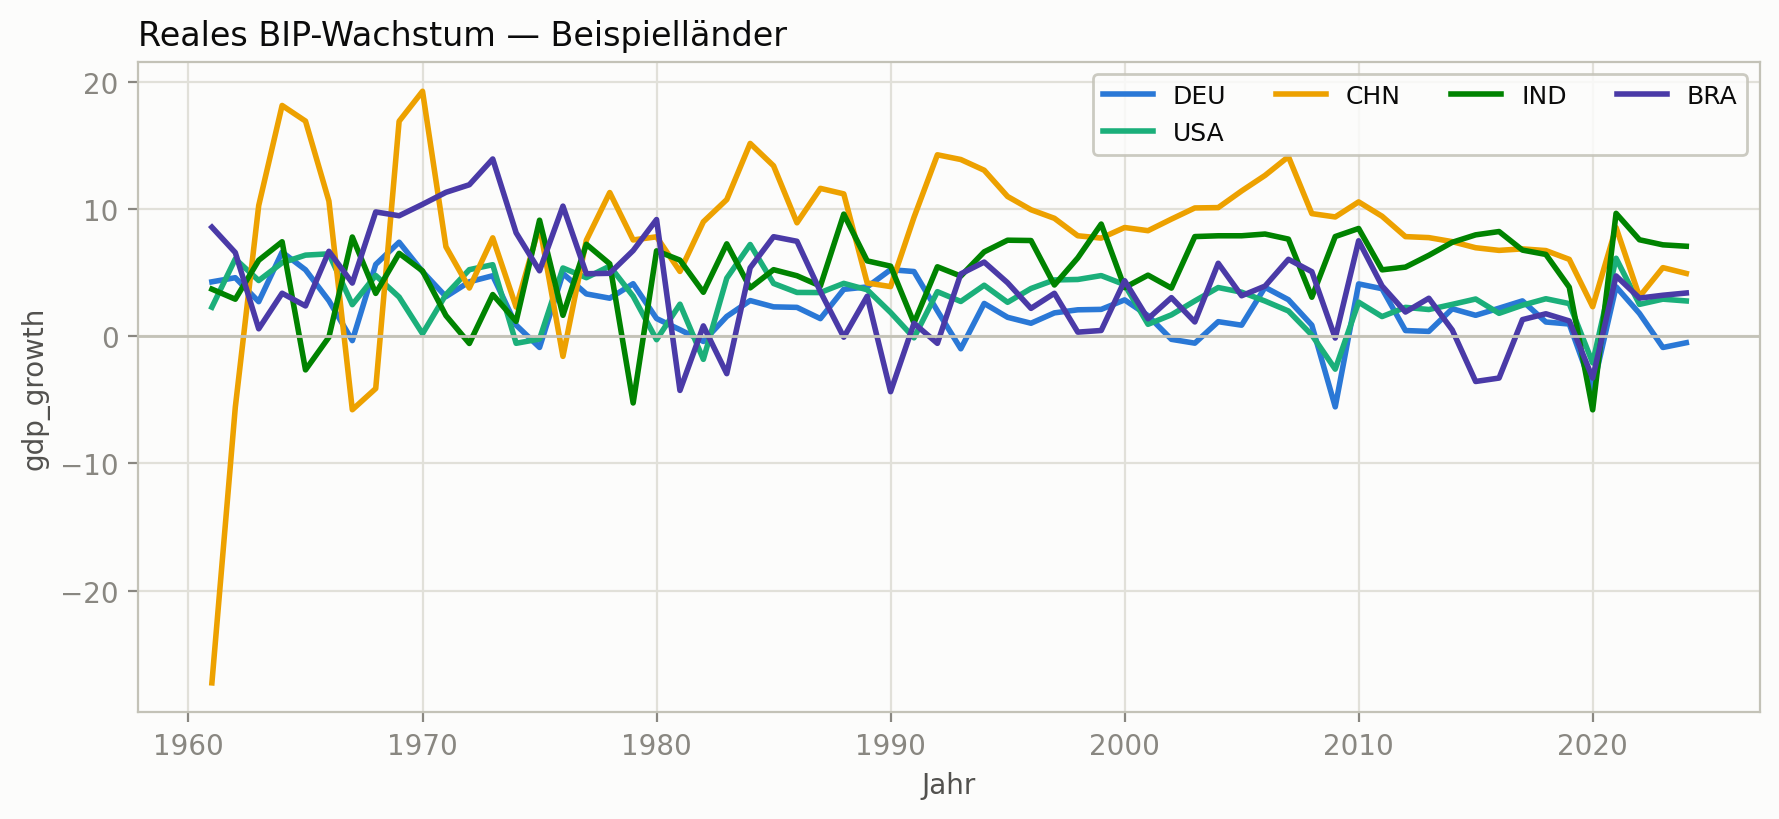

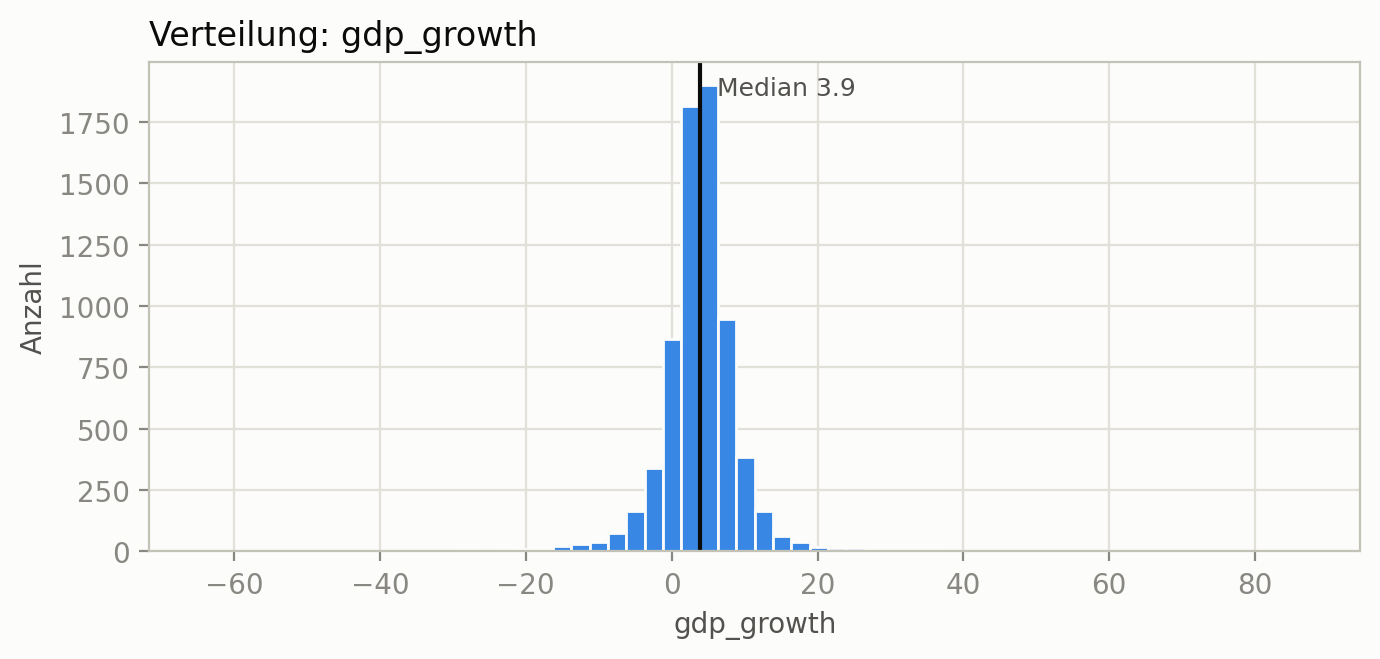

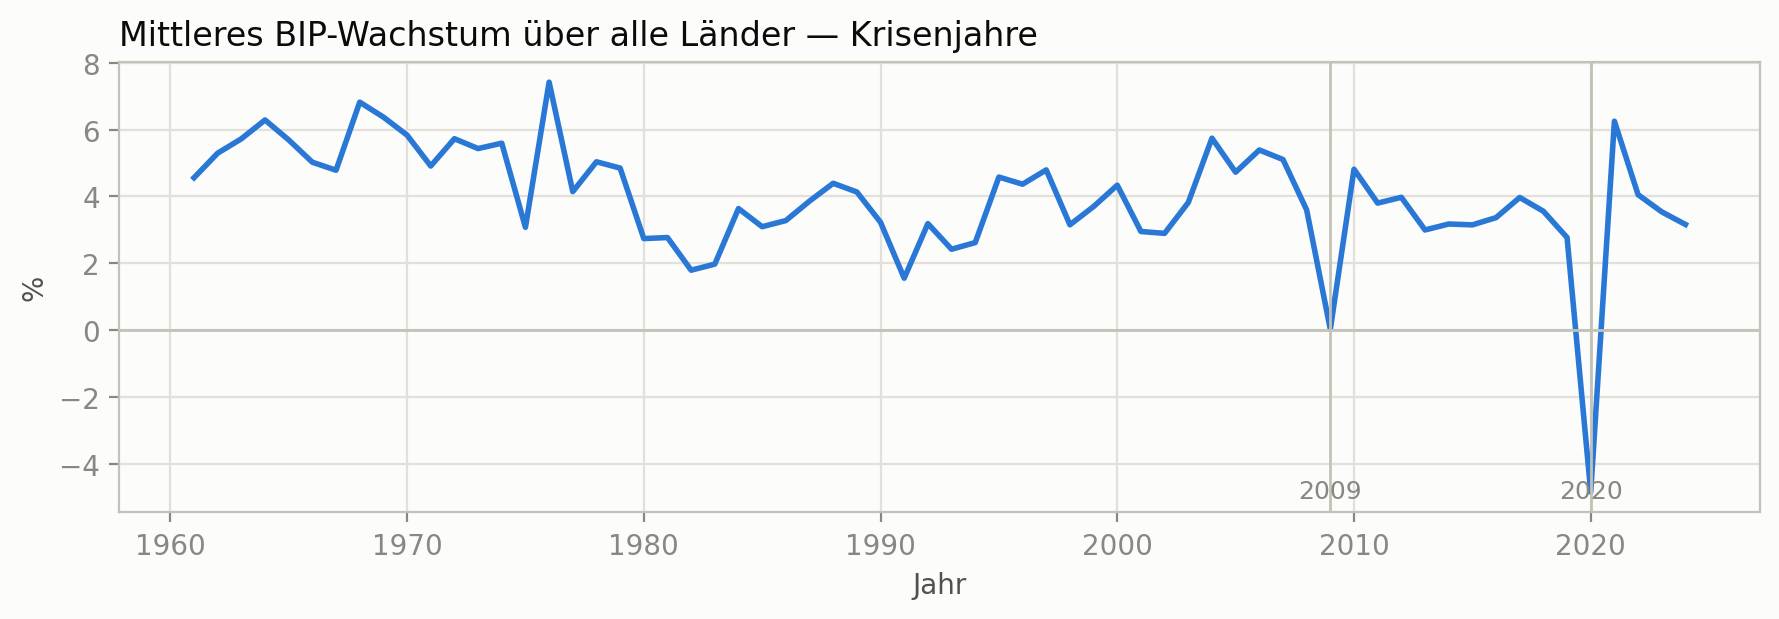

In [8]:
beispiele = [c for c in ["DEU", "USA", "CHN", "IND", "BRA", "NGA"]
             if c in panel_f["country"].unique()]
plotting.plot_country_series(panel_f, beispiele,
                             title="Reales BIP-Wachstum — Beispielländer")
plotting.plot_distribution(panel_f, config.TARGET)

# Globale Krisen im Querschnitt: mittleres Wachstum aller Länder je Jahr
mittel = panel_f.groupby("year")[config.TARGET].mean()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(mittel.index, mittel.values, color=plotting.SERIES_COLORS[0])
for jahr in (2009, 2020):
    ax.axvline(jahr, color=plotting.BASELINE, linewidth=1)
    ax.annotate(str(jahr), (jahr, mittel.min()), color=plotting.MUTED,
                fontsize=9, ha="center", xytext=(0, -2),
                textcoords="offset points")
ax.axhline(0, color=plotting.BASELINE, linewidth=1)
ax.set_title("Mittleres BIP-Wachstum über alle Länder — Krisenjahre",
             loc="left")
ax.set_xlabel("Jahr"); ax.set_ylabel("%")
plt.tight_layout(); plt.show()

### 3.5 Explorative Analyse

Bevor wir aufbereiten, folgt ein breiterer Blick auf das gefilterte Panel. Wie verhält sich die Zielgröße über Länder, Regionen und Zeit, und was bedeutet das für die Modellierung?

**Das ganze Panel auf einen Blick.** Jede Zeile ist ein Land, gruppiert nach Region, jede Spalte ein Jahr. Blau steht für Wachstum, rot für Rezession.

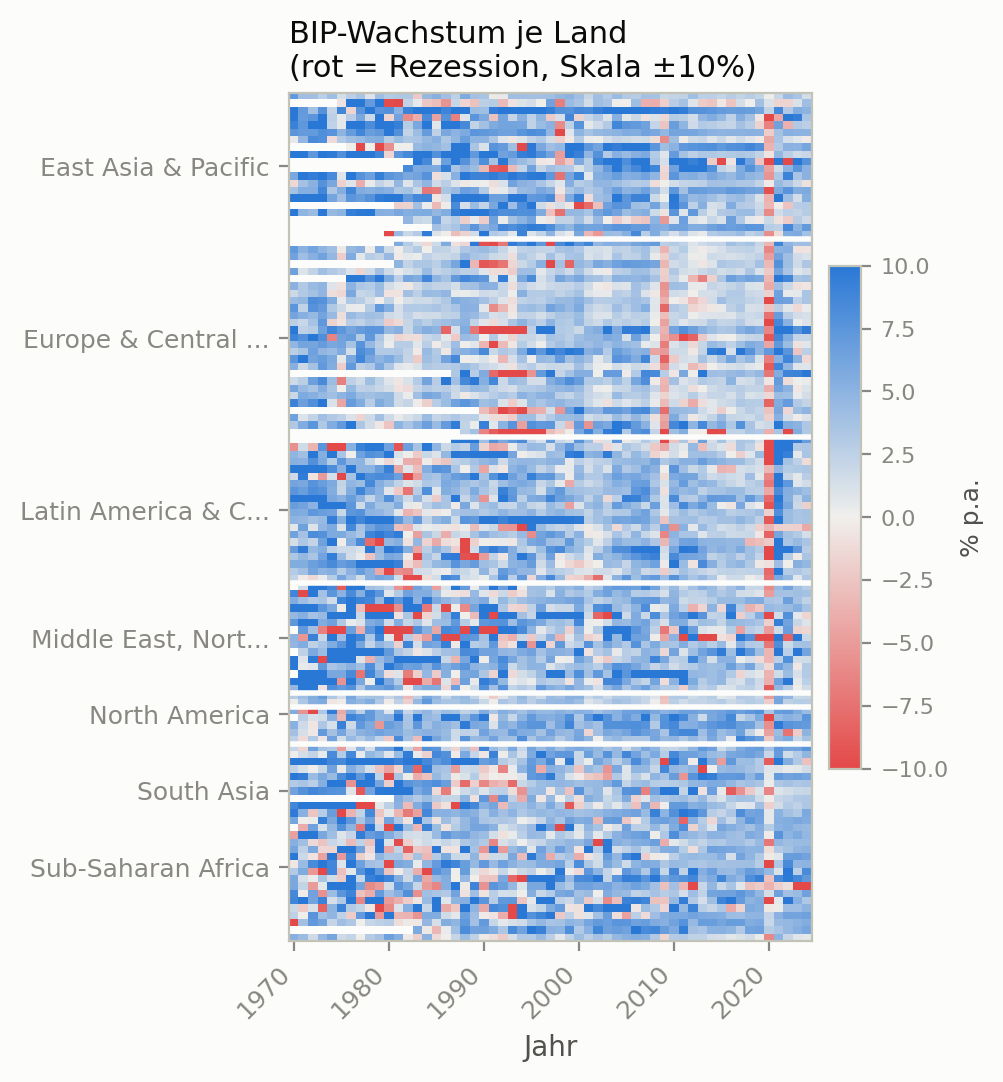

Gespeichert: data/results/heatmap_bip_wachstum.svg


In [9]:
# figsize in Zoll; 13x14 cm passt als kompakte Kachel auf eine halbe
# Praesentationsfolie (cm / 2.54 = Zoll).
fig, ax = plotting.plot_growth_heatmap(panel_f, meta, figsize=(13 / 2.54, 14 / 2.54))
plt.show()

# Als SVG mit transparentem Hintergrund speichern, fuer die direkte
# Einbettung in eine Praesentation (verlustfrei skalierbar, passt sich der
# Folienfarbe an statt eines sichtbaren Kastens).
out_svg = config.RESULTS_DIR / "heatmap_bip_wachstum.svg"
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(out_svg, format="svg", transparent=True, bbox_inches="tight")
print("Gespeichert:", config.rel(out_svg))

Drei Muster springen heraus. Die **globalen Krisen 2009 und 2020** ziehen sich als rote vertikale Streifen durch fast alle Regionen, Rezessionen sind also stark synchronisiert. Das rechtfertigt den Krisen-Dummy und macht Cross-Learning wertvoll. In **Europa und Zentralasien** liegt zu Beginn der 1990er Jahre ein breites rotes Band, die Transformationsrezessionen der postsowjetischen Staaten. **Subsahara-Afrika und Lateinamerika** zeigen vor etwa 1995 deutlich mehr rote Flecken, das sind die Schuldenkrisen der 1980er Jahre. Danach wird das Bild ruhiger, Datenqualität und Wachstumsstabilität nehmen zu.

**Regionale Wachstumspfade**, grau hinterlegt jeweils der globale Mittelwert als Referenz.

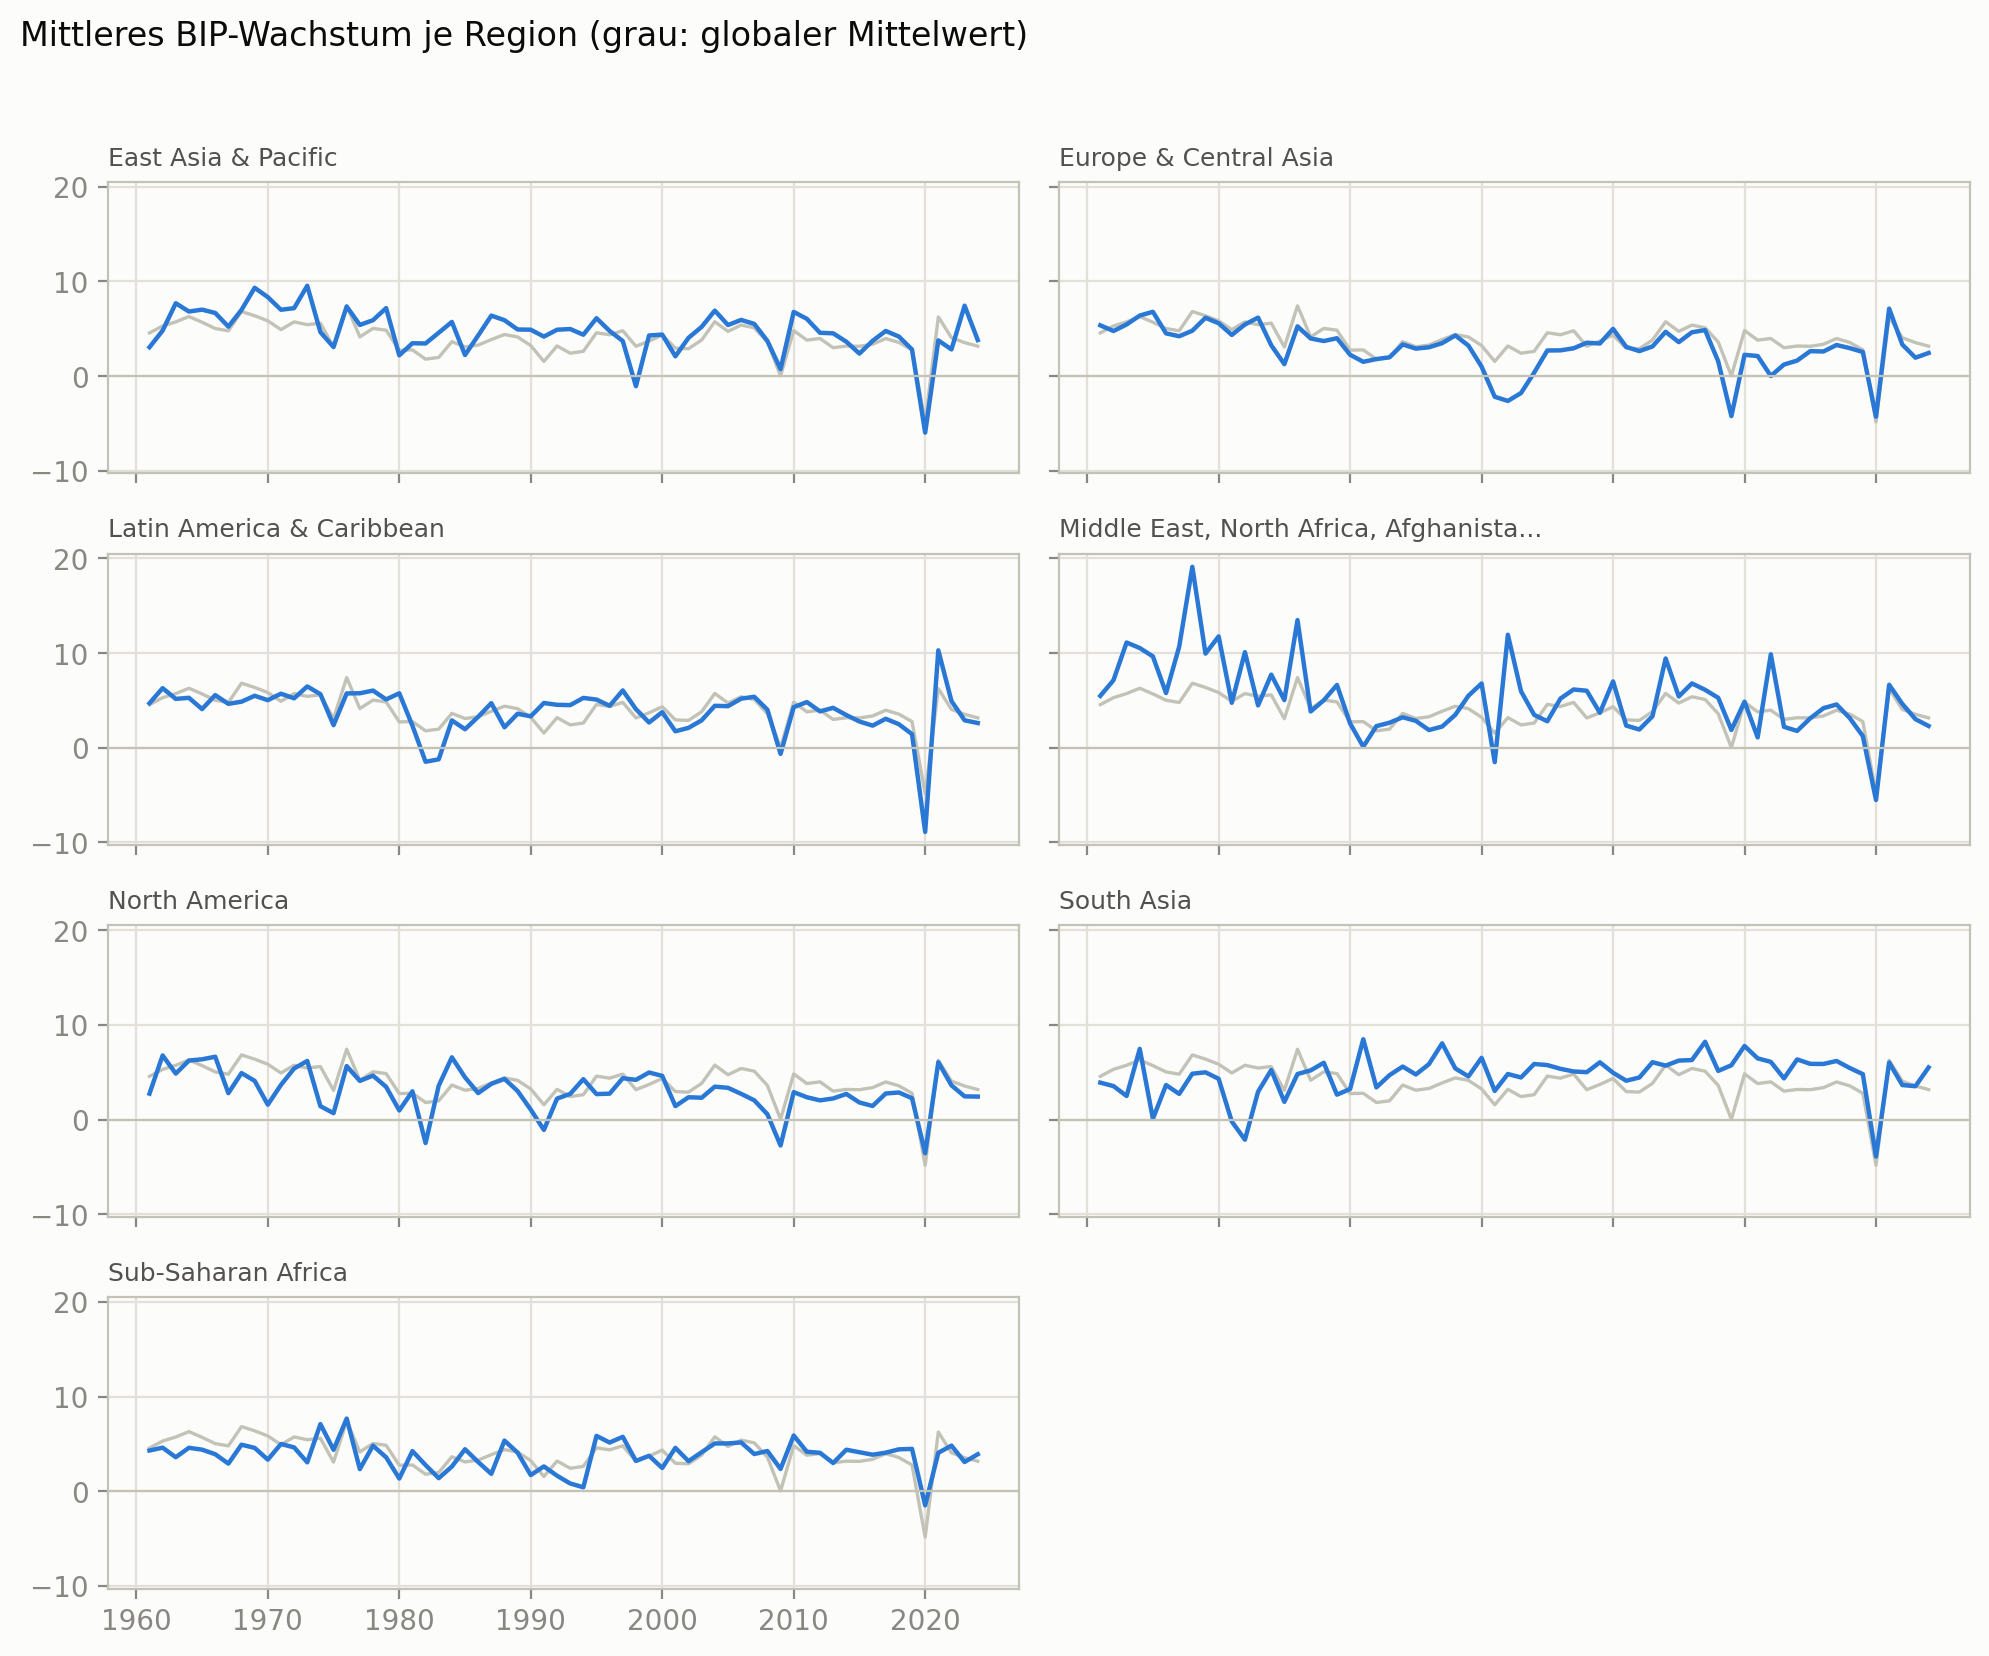

In [10]:
plotting.plot_region_growth(panel_f, meta)
plt.show()

Die Regionen bewegen sich erkennbar **gemeinsam** entlang globaler Zyklen, behalten aber einen eigenen Charakter. Der Nahe Osten schwankt am stärksten, was am Ölpreis liegt. Südasien wächst seit den 1980er Jahren stabil über dem globalen Mittel. Ostasien zeigt Boom-Charakter mit einzelnen tiefen Einbrüchen, die Asienkrise 1997/98 ist im Regionsmittel gut sichtbar. Für die Modelle heißt das zweierlei. Es gibt **gemeinsame globale Faktoren**, die für ein globales Modell sprechen, und zugleich persistente Unterschiede zwischen Ländern und Regionen, die für statische Features wie Region und Einkommensgruppe im TFT sprechen.

**Verteilungen der Rohvariablen**

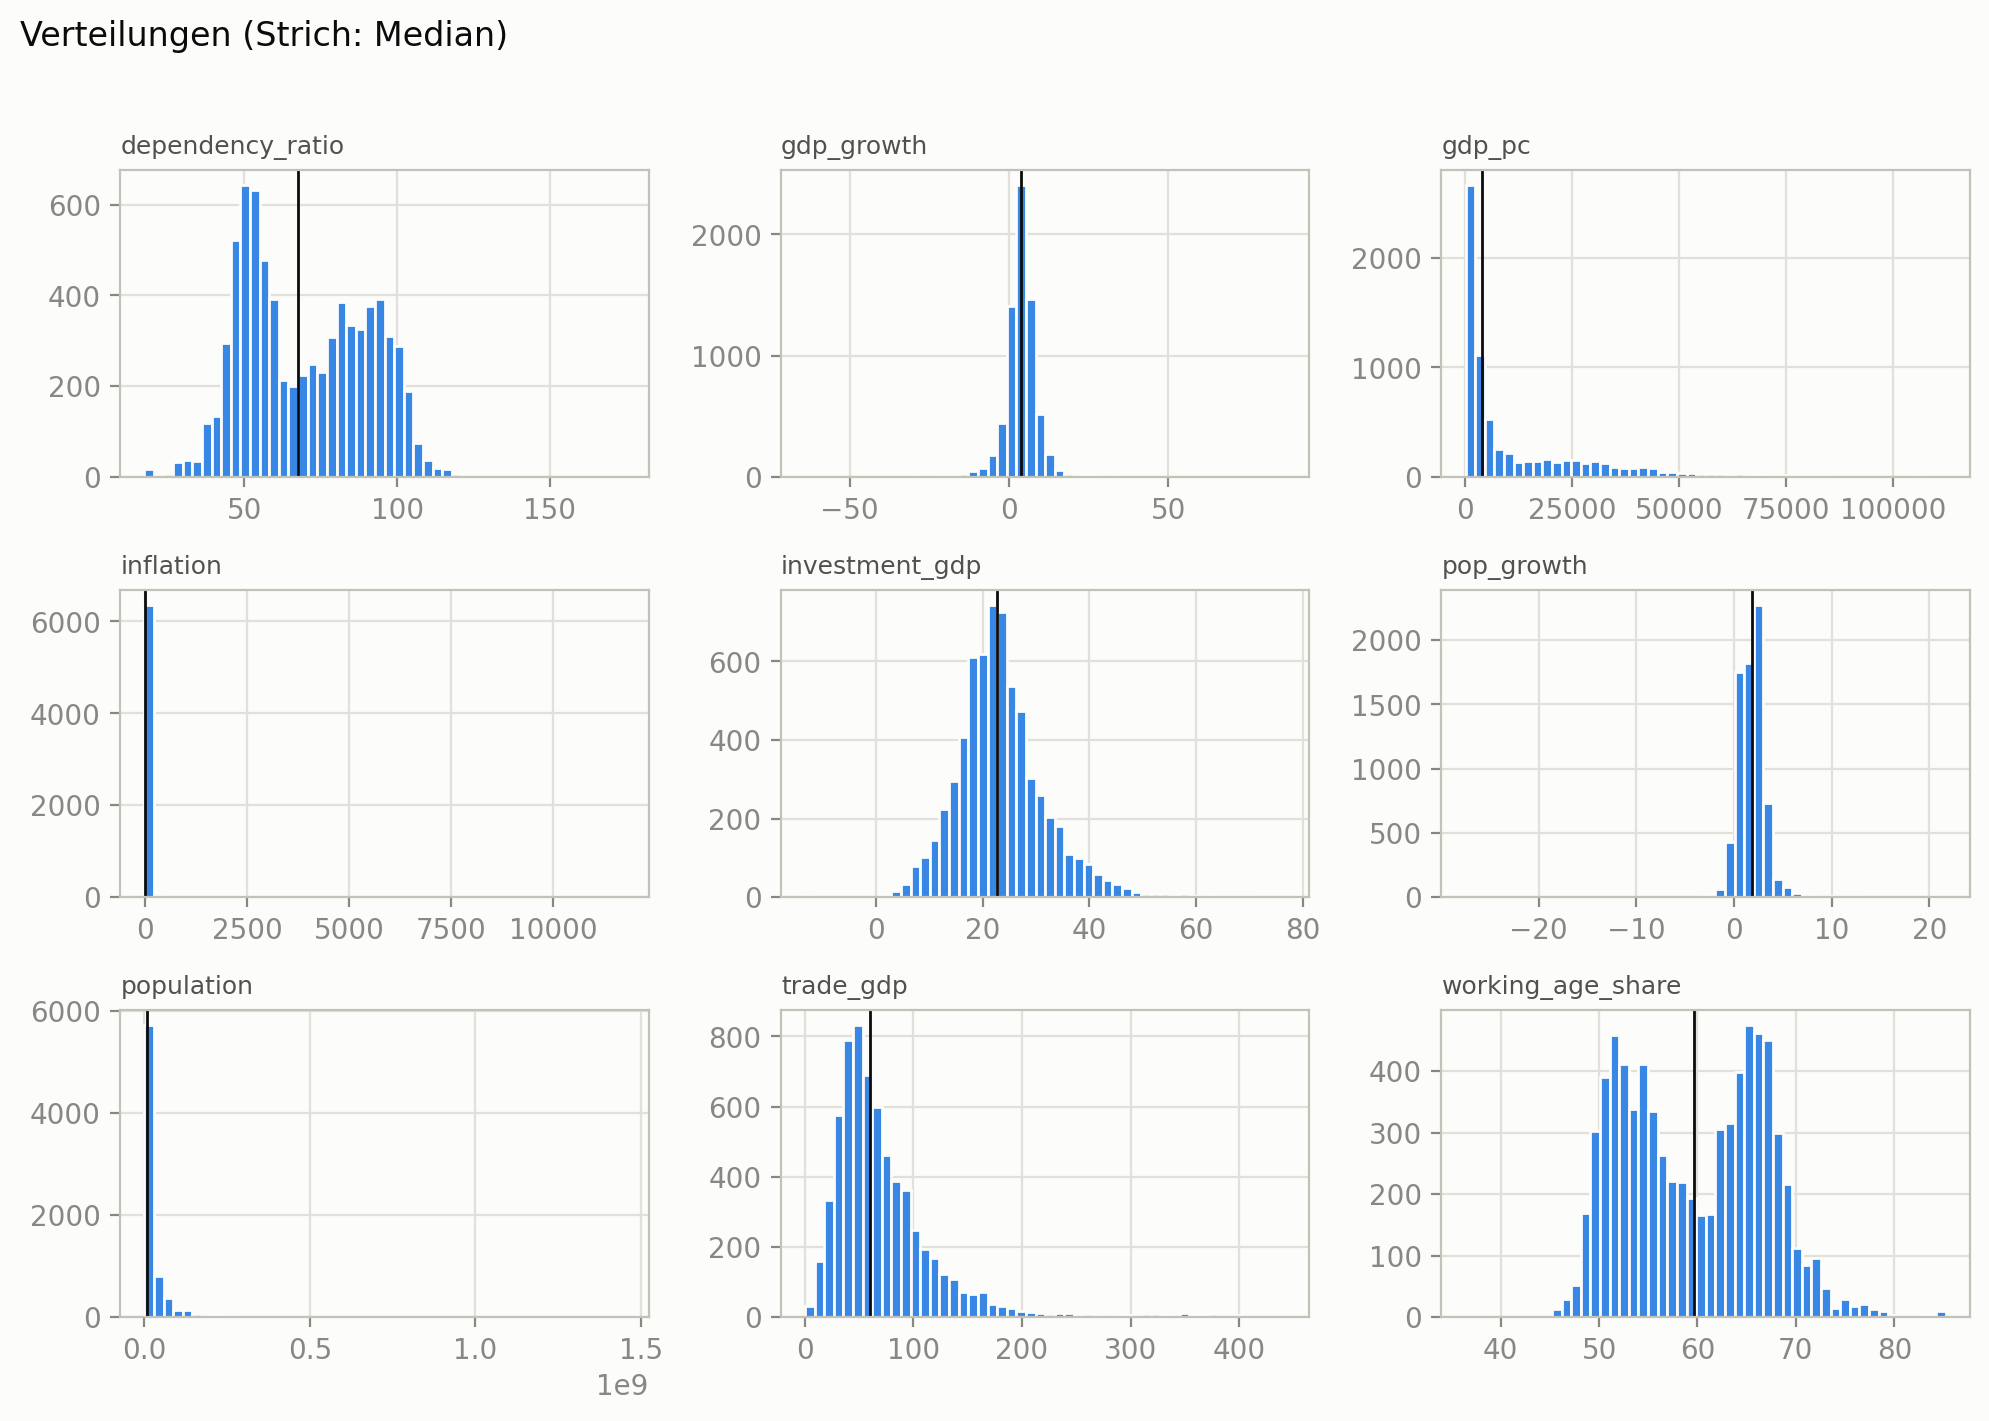

In [11]:
plotting.plot_histogram_grid(panel_f)
plt.show()

Zwei Verteilungen begründen unmittelbar die Transformationen in Abschnitt 4. `gdp_pc` ist extrem rechtsschief, zwischen den ärmsten und den reichsten Ländern liegt mehr als der Faktor 100, deshalb der **Logarithmus**. `inflation` hat Hyperinflations-Ausreißer bis in die Zehntausende Prozent, deshalb die Transformation **sign mal log1p**. Die Demografie-Variablen sind dagegen gutartig verteilt.

**Wie viel Gedächtnis hat die Zielgröße?** Der folgende Plot zeigt die Lag-1-Autokorrelation des Wachstums je Land.

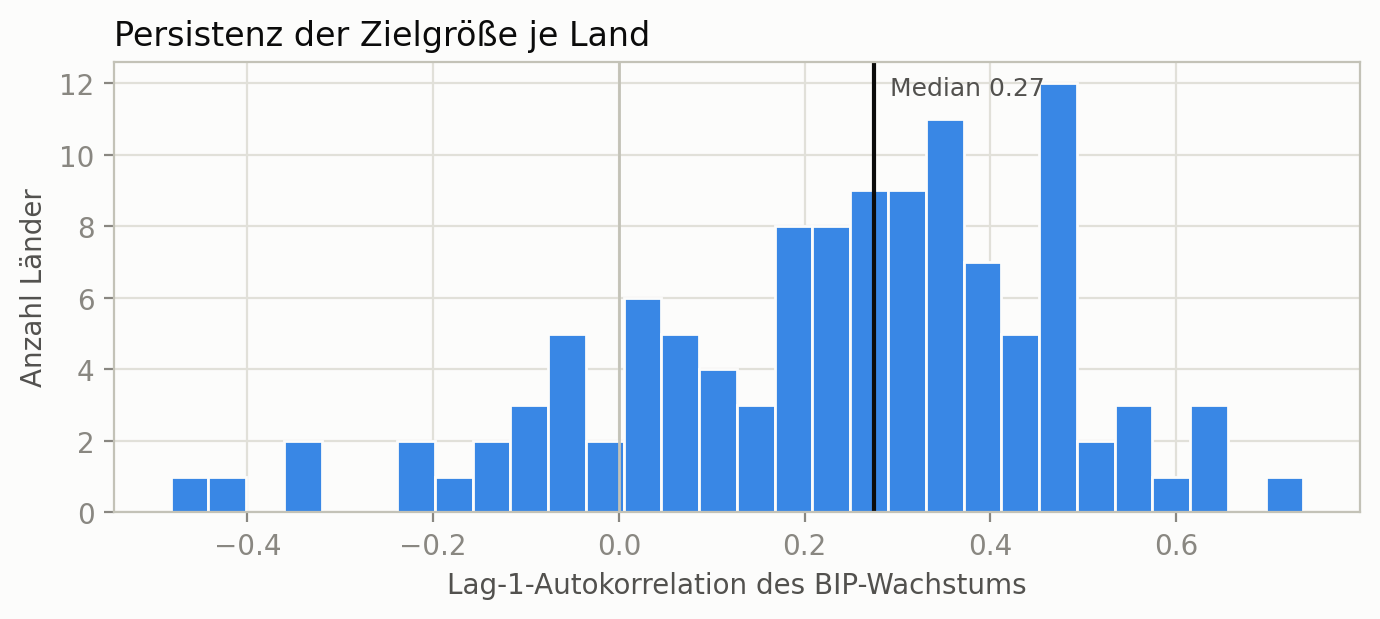

Median AR(1): 0.27 | Anteil Länder mit |AR(1)| < 0.3: 53%


In [12]:
fig, ax, ar1 = plotting.plot_persistence(panel_f)
plt.show()
print(f"Median AR(1): {ar1.median():.2f} | "
      f"Anteil Länder mit |AR(1)| < 0.3: {(ar1.abs() < 0.3).mean()*100:.0f}%")

Das ist die **wichtigste Erkenntnis der Exploration**. Der Median der Lag-1-Autokorrelation liegt nur bei etwa 0,27, bei rund der Hälfte der Länder unter 0,3 im Betrag. BIP-Wachstum hat also wenig ausbeutbare Eigendynamik. Genau deshalb ist der **Random Walk als Baseline so schwer zu schlagen**, und genau deshalb setzen wir auf exogene Treiber und Cross-Learning statt auf reine Autoregression. Diese Zahl gehört in die Abschlusspräsentation.

**Volatilität nach Einkommensgruppe**

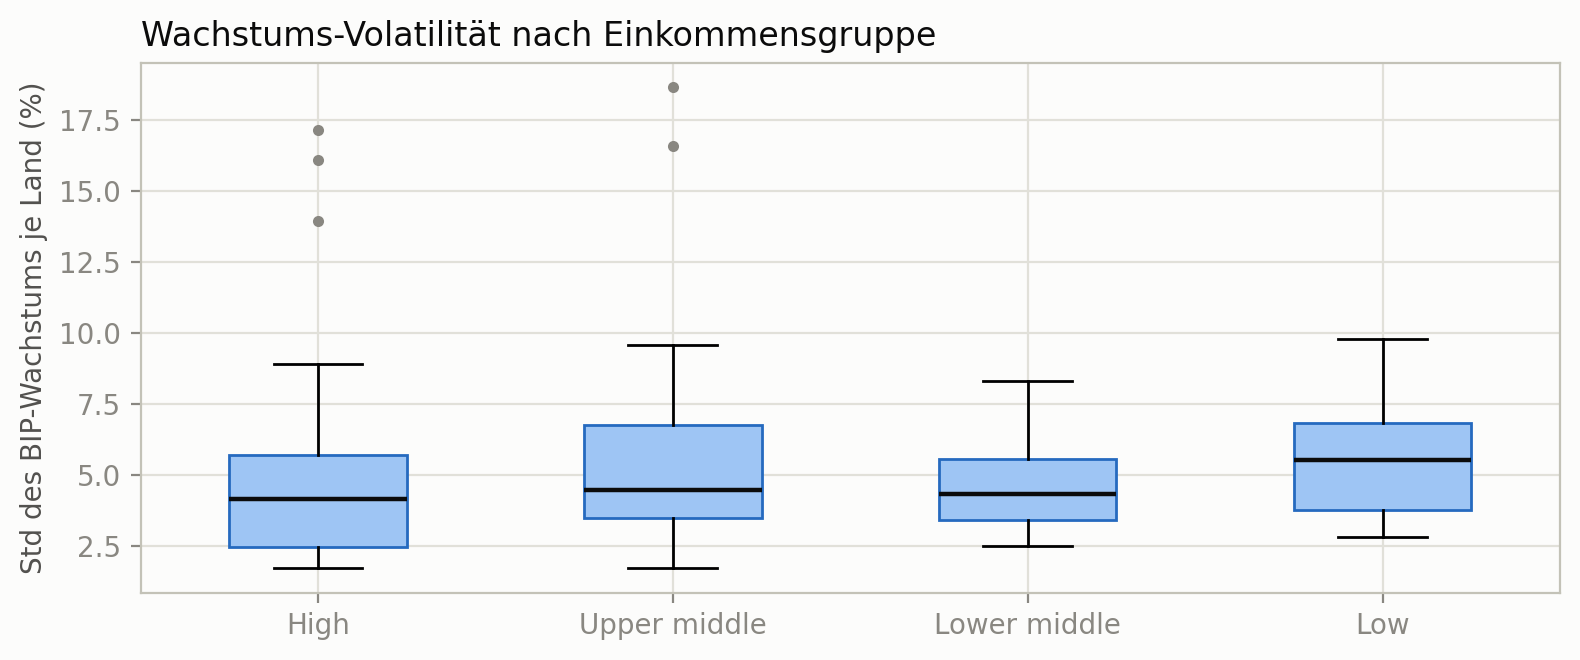

In [13]:
plotting.plot_volatility_by_income(panel_f, meta)
plt.show()

Ärmere Länder schwanken deutlich stärker. Der Median der Standardabweichung liegt in der Gruppe Low income bei etwa 5,5 gegenüber etwa 4,2 bei High income, mit erheblich mehr Extremfällen. Ein globales Modell muss deshalb **je Serie skalieren**, wie es im Deep Learning üblich ist, und die Evaluation braucht eine **skalenfreie Metrik**. Unser Primärkriterium MASE ist genau dafür gemacht.

**Zusammenhänge zwischen den Variablen**

Zum Abschluss der Exploration alle Variablen gegeneinander, als Spearman-Rangkorrelation. Die Rangkorrelation ist hier die passende Wahl, weil sie robust gegenüber den stark schiefen Verteilungen von Inflation und Pro-Kopf-BIP ist und auch monotone, aber nichtlineare Zusammenhänge erfasst.

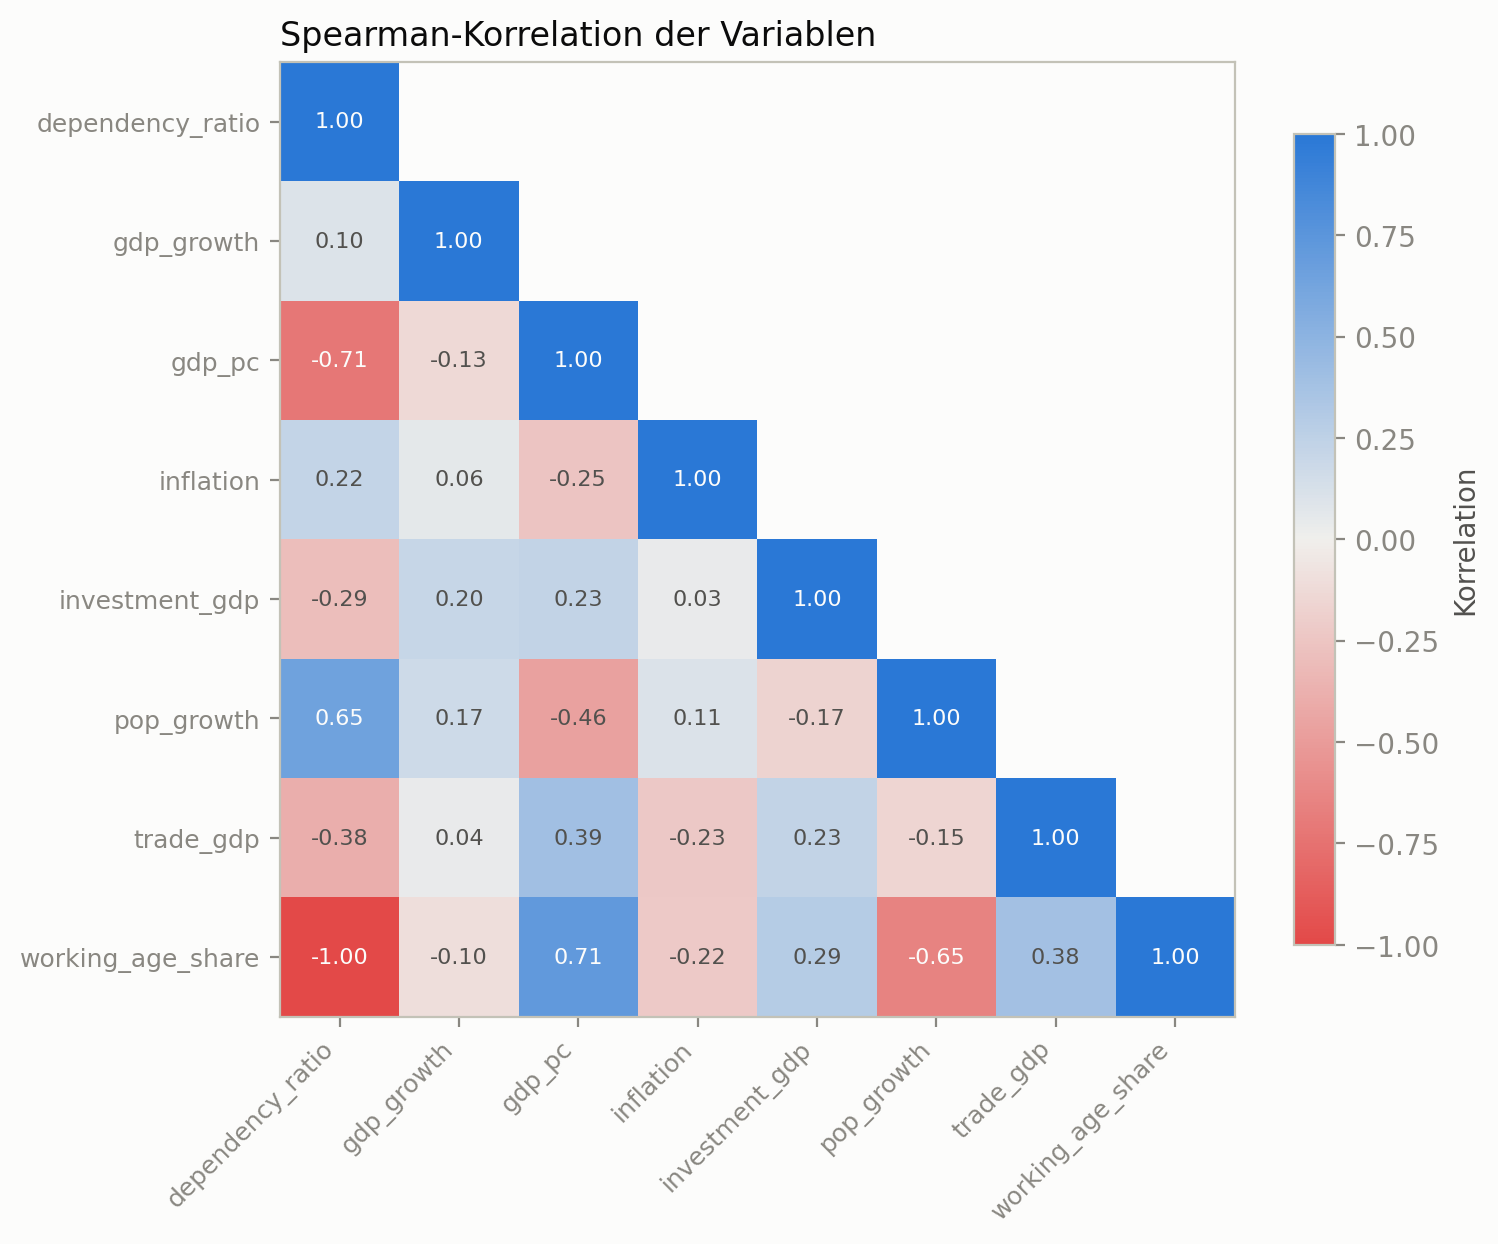

Variablenpaare mit |Spearman| > 0,7
  dependency_ratio     gdp_pc               -0.714
  dependency_ratio     working_age_share    -1.000
  gdp_pc               working_age_share    +0.714


In [14]:
# Die Referenzgroesse population fliesst nicht in die Modelle ein und
# bleibt deshalb aussen vor.
spalten = [c for c in panel_f.columns
           if c not in ("country", "year", *config.REFERENCE_ONLY)]

fig, ax, corr = plotting.plot_correlation_matrix(panel_f, columns=spalten)
plt.show()

# Auffaellige Paare gezielt herausschreiben, damit Redundanz nicht nur
# farblich, sondern auch als Zahl belegt ist.
import itertools
print("Variablenpaare mit |Spearman| > 0,7")
for a, b in itertools.combinations(spalten, 2):
    wert = corr.loc[a, b]
    if abs(wert) > 0.7:
        print(f"  {a:20s} {b:20s} {wert:+.3f}")

Ein Befund sticht sofort heraus. `working_age_share` und `dependency_ratio` haben eine Rangkorrelation von exakt **−1,00**, tragen also **dieselbe Information**. Das ist kein Zufall, sondern folgt direkt aus ihrer Definition:

* `working_age_share` ist der Anteil der 15- bis 64-Jährigen an der Gesamtbevölkerung
* `dependency_ratio` setzt die übrigen Altersgruppen ins Verhältnis zu genau dieser Gruppe, also `(100 − working_age_share) / working_age_share * 100`

Auf unseren Daten nachgerechnet stimmt diese Formel bis auf Rundungsdifferenzen von höchstens 0,004 Prozentpunkten. Die eine Variable lässt sich damit exakt aus der anderen berechnen, sie ist keine zusätzliche Information, sondern nur eine andere Schreibweise derselben Altersstruktur. Dass die Rangkorrelation exakt −1 ist, die Pearson-Korrelation aber nur −0,99 beträgt, liegt allein daran, dass der Zusammenhang zwar streng monoton, aber nicht linear ist.

Damit erklärt sich auch das spiegelbildliche Muster gegenüber dem Ziel, das in Abschnitt 4.1 noch einmal auftaucht. Die Korrelation mit `gdp_growth` liegt bei −0,10 für `working_age_share` und bei +0,10 für `dependency_ratio`, also derselbe Zusammenhang mit umgekehrtem Vorzeichen.

Für die Modellierung ist das relevant:

* Für lineare Verfahren mit exogenen Regressoren, etwa SARIMAX, bedeuten zwei perfekt gekoppelte Regressoren nahezu perfekte Multikollinearität. Die einzelnen Koeffizienten werden dadurch instabil und nicht mehr sinnvoll interpretierbar, auch wenn die Prognosegüte selbst darunter kaum leidet.
* Für den Temporal Fusion Transformer und Chronos-2 ist es unkritischer, kostet aber Kapazität in der Variablenauswahl, weil zwei Eingänge exakt dieselbe Größe beschreiben.

Das Feature-Set bleibt an dieser Stelle bewusst unverändert, denn eine der beiden Variablen zu entfernen wäre eine Modellentscheidung und würde die Ergebnisse der Notebooks 02 bis 05 verschieben. Der Befund gehört aber in die Diskussion und ist ein naheliegender Kandidat für eine Bereinigung.

Der zweite auffällige Block betrifft beide Demografievariablen gegenüber `gdp_pc` mit einem Betrag von 0,71. Reichere Länder haben systematisch einen höheren Erwerbsanteil. Genau dieses Confounding steckt hinter der scheinbar verkehrten Vorzeichenlage der Demografie, die in Abschnitt 4.1 ausführlicher besprochen wird.

## 4 Data Preparation

Drei Schritte, alle als wiederverwendbare Funktionen in `src/data_utils.py`:

1. **Kleine innere Lücken interpolieren**, höchstens 2 Jahre, linear und je Land getrennt. Ränder werden nicht extrapoliert und das Ziel wird **nie** imputiert. Die folgende Zelle weist aus, wie viele Werte je Spalte gefüllt wurden und welche Länder davon betroffen sind.
2. **Lag-Features bilden**. Alle `PAST_ONLY`-Variablen gehen als t−1-Werte ein, `gdp_pc` wird vorher logarithmiert und dient als Konvergenz-Feature. Die kontemporären Spalten werden gelöscht, damit Leakage konstruktiv ausgeschlossen bleibt.
3. **Krisen-Dummy setzen** für 2009 und 2020. Diese Jahre sind historisch bekannt, für Zukunftsprognosen wird der Dummy immer auf 0 gesetzt, was im Meta-File dokumentiert ist.

Zum Krisen-Dummy gehört eine wichtige Einschränkung. Er markiert **ausschließlich globale** Krisen, also die Finanzkrise 2009 und den COVID-Einbruch 2020. **Regionale** Krisen bleiben unberücksichtigt, etwa die Asienkrise 1997/98, die Transformationsrezessionen der postsowjetischen Staaten zu Beginn der 1990er Jahre oder die lateinamerikanischen Schuldenkrisen der 1980er Jahre. In der Heatmap und in den Regionsplots weiter oben sind diese Ereignisse deutlich zu erkennen, für die Modelle bleiben sie jedoch unerklärtes Rauschen. Ein regionaler oder länderspezifischer Krisenindikator wäre daher ein naheliegender Ansatzpunkt für eine Erweiterung und gehört in den Ausblick.

In [15]:
panel_i, fill_report = data_utils.interpolate_gaps(panel_f)
print("Interpolierte Werte je Spalte")
print(fill_report)

# Welche Länder waren betroffen? Vergleich der fehlenden Werte vor und nach der
# Interpolation, aufsummiert je Land über alle interpolierten Spalten.
luecken_spalten = fill_report.index.tolist()
vorher = panel_f.set_index(["country", "year"])[luecken_spalten].isna()
nachher = panel_i.set_index(["country", "year"])[luecken_spalten].isna()
gefuellt_je_land = ((vorher & ~nachher).groupby(level="country").sum()
                    .sum(axis=1)
                    .pipe(lambda s: s[s > 0].sort_values(ascending=False)))

print(f"\nBetroffen sind {len(gefuellt_je_land)} von "
      f"{panel_f['country'].nunique()} Ländern mit zusammen "
      f"{int(gefuellt_je_land.sum())} gefüllten Werten.")
print("\nLänder mit den meisten gefüllten Werten")
print(gefuellt_je_land.head(10))

panel_final = data_utils.add_lagged_features(panel_i)
panel_final = data_utils.add_crisis_dummy(panel_final)

feature_cols = [c for c in panel_final.columns if c not in ("country", "year")]
print("\nFinale Spalten:", feature_cols)
panel_final.tail(3)

Interpolierte Werte je Spalte
                   values_filled
pop_growth                     2
working_age_share              0
gdp_pc                         0
investment_gdp                 9
trade_gdp                      6
inflation                      7

Betroffen sind 13 von 116 Ländern mit zusammen 24 gefüllten Werten.

Länder mit den meisten gefüllten Werten
country
LKA    4
BRN    2
COG    2
GHA    2
BHS    2
IRQ    2
RWA    2
TCD    2
SDN    2
OMN    1
dtype: int64

Finale Spalten: ['dependency_ratio', 'gdp_growth', 'pop_growth', 'working_age_share', 'log_gdp_pc_lag1', 'investment_gdp_lag1', 'trade_gdp_lag1', 'inflation_log_lag1', 'is_global_crisis']


,country,year,dependency_ratio,gdp_growth,pop_growth,working_age_share,log_gdp_pc_lag1,investment_gdp_lag1,trade_gdp_lag1,inflation_log_lag1,is_global_crisis
13972,ZAF,2022,48.550466,2.058137,1.413972,67.317190,8.657113,12.835552,56.164714,1.726108,0
13973,ZAF,2023,48.367934,0.806105,1.328101,67.400008,8.663346,15.672109,64.947134,2.084413,0
13974,ZAF,2024,48.311417,0.534844,1.249514,67.425693,8.658094,15.391317,65.679876,1.956602,0


### 4.1 Kurzer Blick auf das finale Panel

Der folgende Plot zeigt den Zusammenhang der **Modell-Features** mit dem Ziel, und zwar genau so, wie die Modelle sie später sehen werden, also gelaggt und transformiert. Es handelt sich um gepoolte Rangkorrelationen über alle Länder und Jahre.

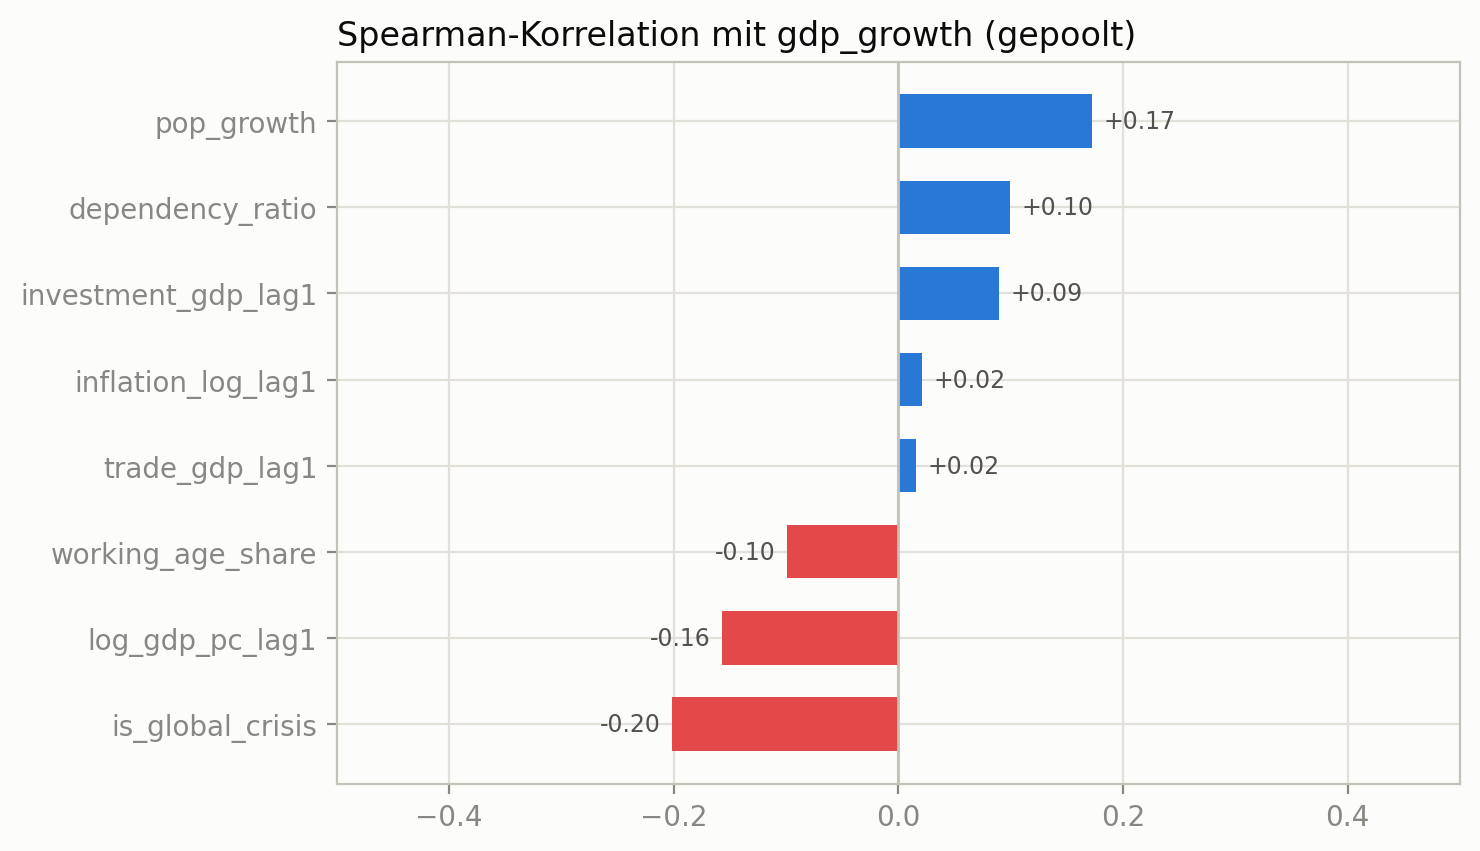

In [16]:
plotting.plot_target_correlations(panel_final)
plt.show()

Die Vorzeichen erzählen eine ökonomisch schlüssige Geschichte, mit einer lehrreichen Falle:

* `is_global_crisis` (−0,20) und `log_gdp_pc_lag1` (−0,16) sind die stärksten Zusammenhänge. Krisenjahre drücken das Wachstum, und **reichere Länder wachsen langsamer**. Das ist der klassische Konvergenz- oder Aufholeffekt und unser wichtigstes ökonomisches Signal.
* `investment_gdp_lag1` (+0,09) wirkt positiv, genau wie es das Solow-Modell erwarten lässt. `trade_gdp_lag1` und `inflation_log_lag1` liegen gepoolt nahe null, ihre Wirkung ist nichtlinear beziehungsweise länderspezifisch und lässt sich erst in den Modellen auflösen.
* **Die Falle.** `dependency_ratio` korreliert gepoolt *positiv* (+0,10) und `working_age_share` *negativ* (−0,10) mit dem Wachstum, also scheinbar entgegen der demografischen Dividende. Dahinter steckt ein Confounding-Artefakt. Arme Länder haben hohe Abhängigenquoten und zugleich hohes Aufholwachstum. Der Querschnittseffekt zwischen arm und reich überdeckt damit den Zeitreiheneffekt des Demografie-Wandels innerhalb eines Landes. Gepoolte Korrelationen sind hier also kein Kausalitätsbeweis. Genau deshalb nutzen wir Modelle, die Länder-Heterogenität abbilden können, etwa SARIMAX je Land und den TFT mit statischen Features.

## 5 Backtest-Konvention, verbindlich für alle Modelle

**Walk-forward mit expanding window**, definiert in `src.config`:

* Backtest-Origins **1999, 2004, 2009 und 2014** sowie der finale Holdout-Origin **2019**
* Horizont **H = 5 Jahre**, der finale Test prognostiziert also 2020 bis 2024. Das ist bewusst hart gewählt, denn COVID liegt im Testfenster und stellt die Unsicherheitsintervalle auf eine ehrliche Probe.
* **Nie shufflen.** Der Split verläuft ausschließlich entlang der Zeit über `data_utils.train_test_split(panel, origin)` beziehungsweise `data_utils.iter_backtest_folds(panel)`.

Primärmetrik ist **MASE**, ergänzt um Pinball-Loss und Coverage für die Intervalle. Beides ist in `src/evaluation.py` implementiert.

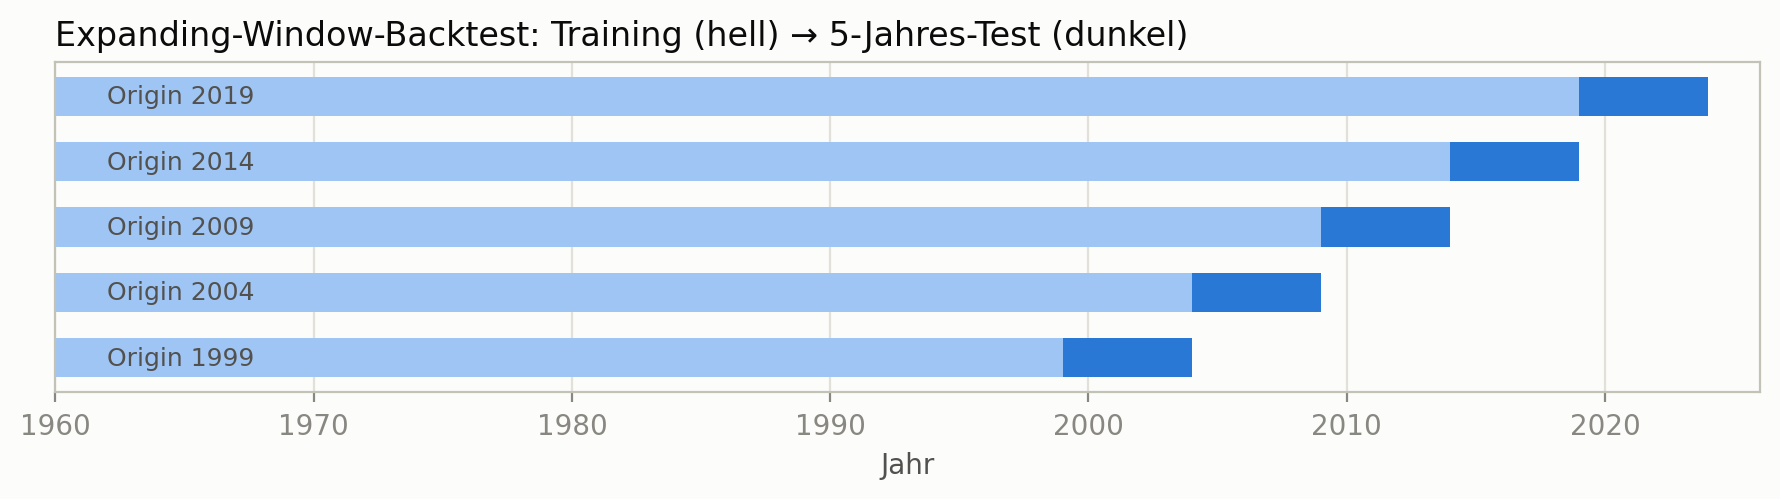

In [17]:
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, origin in enumerate(config.ALL_ORIGINS):
    ax.barh(i, origin - 1960, left=1960, color=plotting.SEQ_BLUES[1], height=0.6)
    ax.barh(i, config.HORIZON, left=origin, color=plotting.SERIES_COLORS[0], height=0.6)
    ax.annotate(f"Origin {origin}", (1962, i), va="center", fontsize=9,
                color=plotting.INK_SECONDARY)
ax.set_yticks([])
ax.set_xlim(1960, 2026)
ax.set_title("Expanding-Window-Backtest: Training (hell) → 5-Jahres-Test (dunkel)",
             loc="left")
ax.set_xlabel("Jahr")
plt.tight_layout(); plt.show()

## 6 Export für die Notebooks 02 bis 05

In [18]:
import json

# --- Sanity-Checks vor dem Export --------------------------------------
assert panel_final.duplicated(["country", "year"]).sum() == 0
assert panel_final[config.TARGET].notna().sum() > 5000   # genug Zielwerte
assert "investment_gdp" not in panel_final.columns       # nur gelaggt!
assert {"investment_gdp_lag1", "log_gdp_pc_lag1"} <= set(panel_final.columns)

# --- Panel speichern ----------------------------------------------------
config.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
panel_final.to_csv(config.PANEL_CSV, index=False)

# --- Länder-Metadaten, statische Features für TFT und Chronos -----------
meta[meta["country"].isin(panel_final["country"].unique())].to_csv(
    config.PROCESSED_DIR / "countries_static.csv", index=False)

# --- Daten-Wörterbuch und Konventionen als JSON -------------------------
lag = config.LAG_YEARS
daten_woerterbuch = {
    "gdp_growth": "ZIEL, reales BIP-Wachstum in Prozent pro Jahr",
    "pop_growth": "exogen, im Voraus bekannt, Bevölkerungswachstum in Prozent pro Jahr",
    "working_age_share": "exogen, im Voraus bekannt, Anteil der 15- bis 64-Jährigen in Prozent",
    "dependency_ratio": "exogen, im Voraus bekannt, Abhängigenquote in Prozent",
    f"log_gdp_pc_lag{lag}": "exogen, gelaggt, log BIP pro Kopf (t-1), Konvergenz",
    f"investment_gdp_lag{lag}": "exogen, gelaggt, Investitionen in Prozent des BIP (t-1)",
    f"trade_gdp_lag{lag}": "exogen, gelaggt, Handel in Prozent des BIP (t-1)",
    f"inflation_log_lag{lag}": "exogen, gelaggt, sign(x) mal log1p(|x|) der Inflation (t-1)",
    "is_global_crisis": "Dummy für 2009 und 2020, für Zukunftsjahre auf 0 setzen",
}

# Das Wörterbuch muss die tatsächlichen Panel-Spalten beschreiben, sonst
# dokumentiert panel_meta.json Spalten, die es gar nicht gibt.
beschriebene_lags = {k for k in daten_woerterbuch if "_lag" in k}
tatsaechliche_lags = {c for c in panel_final.columns if "_lag" in c}
assert beschriebene_lags == tatsaechliche_lags, (
    "Daten-Wörterbuch passt nicht zum Panel. "
    f"Nur im Wörterbuch {sorted(beschriebene_lags - tatsaechliche_lags)}, "
    f"nur im Panel {sorted(tatsaechliche_lags - beschriebene_lags)}")

panel_meta = {
    "target": config.TARGET,
    "known_future_features": config.KNOWN_FUTURE,
    "lagged_features": [c for c in panel_final.columns if "_lag" in c],
    "static_features_file": "countries_static.csv",
    "horizon": config.HORIZON,
    "backtest_origins": config.BACKTEST_ORIGINS,
    "final_origin": config.FINAL_ORIGIN,
    "quantiles": config.QUANTILES,
    "results_schema": config.RESULTS_COLUMNS,
    "n_countries": int(panel_final["country"].nunique()),
    "years": [int(panel_final["year"].min()), int(panel_final["year"].max())],
    "data_dictionary": daten_woerterbuch,
    "source": "World Bank WDI (CC-BY-4.0), via wbgapi",
}
with open(config.PANEL_META_JSON, "w", encoding="utf-8") as f:
    json.dump(panel_meta, f, ensure_ascii=False, indent=2)

# Pfade relativ zur Projektwurzel, damit die Ausgabe überall gleich aussieht.
print("Gespeichert")
print("  ", config.rel(config.PANEL_CSV))
print("  ", config.rel(config.PROCESSED_DIR / "countries_static.csv"))
print("  ", config.rel(config.PANEL_META_JSON))
print(f"\nPanel mit {panel_final['country'].nunique()} Ländern, "
      f"{panel_final['year'].min()} bis {panel_final['year'].max()}, "
      f"{len(panel_final):,} Zeilen")

Gespeichert
   data/processed/gdp_panel.csv
   data/processed/countries_static.csv
   data/processed/panel_meta.json

Panel mit 116 Ländern, 1960 bis 2024, 7,540 Zeilen


### Kanonische Baseline, Random Walk mit Drift

Neben dem Panel erzeugt Notebook 01 auch die gemeinsame Vergleichs-Baseline. Der Random Walk mit Drift schreibt je Land den zuletzt beobachteten Wert mit dem mittleren Trend fort. Weil das BIP-Wachstum wenig Eigendynamik hat, ist diese naive Prognose bewusst schwer zu schlagen und dient als Referenzpunkt, auch für die skalenfreie MASE.

Sie wird als `data/results/preds_rw_drift.csv` gespeichert, sodass die Modell-Notebooks 02 bis 04 und der Vergleich in Notebook 05 dieselbe Baseline laden, statt sie jeweils neu zu berechnen.

In [19]:
# Kanonische Random-Walk-mit-Drift-Baseline erzeugen und teilen.
# Alle Modell-Notebooks laden diese Datei, statt die Baseline neu zu berechnen.
preds_rw_drift = evaluation.rw_drift_forecast(panel_final)
evaluation.save_predictions(preds_rw_drift, "rw_drift")
preds_rw_drift.head()

Gespeichert: data/results/preds_rw_drift.csv  (2,900 Prognosen)


,model,country,origin_year,year,h,y_true,y_pred,q10,q90
0,rw_drift,ABW,1999,2000,1,7.622921,0.001343,NaN,NaN
1,rw_drift,ABW,1999,2001,2,4.182002,-1.235356,NaN,NaN
2,rw_drift,ABW,1999,2002,3,-0.944953,-2.472056,NaN,NaN
3,rw_drift,ABW,1999,2003,4,1.110505,-3.708755,NaN,NaN
4,rw_drift,ABW,1999,2004,5,7.293728,-4.945454,NaN,NaN


## 7 So nutzen die nächsten Notebooks diese Daten

**Was ist ein Panel?**

Ein Panel ist eine Tabelle mit Beobachtungen für dieselben Einheiten über die Zeit. In diesem Projekt sind die Einheiten die Länder, jede Zeile beschreibt also ein Land in einem bestimmten Jahr. Ein Beispiel:

* Zeile 1, DEU, 1995
* Zeile 2, DEU, 1996
* Zeile 3, FRA, 1995

Dadurch können wir sowohl über die Zeit als auch über die Länder hinweg analysieren. Genau das ist der Unterschied zu einer normalen Tabelle mit nur einer Zeitreihe pro Land.

Die fertigen Daten liegen bereits als breites Panel vor:

* 1 Zeile entspricht einem Land in einem Jahr
* 1 Spalte entspricht einer Variable
* Beispiele für Variablen sind das Ziel `gdp_growth`, Treiber wie `pop_growth` und `working_age_share` sowie gelaggte Features wie `investment_gdp_lag1`

Für neue Notebooks gilt dieser Standard-Workflow:

```python
from src import config, data_utils, evaluation

# 1) Das fertige Panel laden
panel = data_utils.load_panel()          # 1 Zeile pro (country, year)
meta  = data_utils.load_panel_meta()     # Feature-Gruppen, Splits, Ergebnis-Schema

# 2) Struktur prüfen
print(panel.columns.tolist())
print(meta["target"], meta["known_future_features"], meta["lagged_features"])

# 3) Ein Fold erzeugen
train, test = data_utils.train_test_split(panel, origin_year=2019,
                                          horizon=config.HORIZON)

# 4) Über alle Folds iterieren
for origin, train, test in data_utils.iter_backtest_folds(panel):
    # train enthält nur Beobachtungen bis inklusive origin
    # test enthält die nächsten HORIZON Jahre
    pass

# 5) Ergebnisse im Standard-Format speichern
# evaluation.save_predictions(preds_df, "sarimax")   # oder "tft", "chronos2"
```

Wichtige Regeln für alle Modelle:

1. Nie mit dem kompletten Panel ohne Split arbeiten, sondern immer nur mit `train` des jeweiligen Folds.
2. `KNOWN_FUTURE`-Variablen dürfen im Testfenster verwendet werden, weil sie ex ante bekannt sind.
3. `*_lag1`-Variablen dürfen nur so weit verwendet werden, wie sie zum jeweiligen Zeitpunkt tatsächlich verfügbar waren.
4. `is_global_crisis` ist für Zukunftsjahre immer 0.
5. Für den Vergleich sollten Punktprognosen und möglichst auch `q10` und `q90` gespeichert werden.

Kurz gesagt, wer ein neues Notebook schreibt, startet immer mit dem geladenen Panel aus `data_utils.load_panel()` und arbeitet mit den Split-Funktionen aus `data_utils`, statt die Rohdaten direkt zu verwenden.